<a href="https://colab.research.google.com/github/Raziedmar/telecomx-latam/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Telecom X - Análisis de Evasión de Clientes

---

El presente notebook pretende resolver el Challenge de Alura Latam denominado Telecom X - Analis de Evasión de Clientes en el que hay que analizar
datos en una empresa Telecom X en la que se formará parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

El desafío es recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa y a partir del análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

¿Qué haremos?
✅ Importar y manipular datos desde la API de manera eficiente.
✅ Aplicar los conceptos de ETL (Extracción, Transformación y Carga) en la preparación de los datos.
✅ Crear visualizaciones estratégicas para identificar patrones y tendencias.
✅ Realizar un Análisis Exploratorio de Datos (EDA) y generar un informe con insights relevantes.

Vamos a ello!



#📌 Extracción

✅ Cargando los datos directamente desde la API (por incovenientes con url se tuvo que recurrir a cargar desde archivo)
✅ Convirtiendo los datos a un DataFrame de Pandas para facilitar su manipulación.

In [30]:
import pandas as pd
import requests


#url2="https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json"
#url = "https://github.com/alura-cursos/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json"
#url="https://github.com/alura-cursos/challenge2-data-science-LATAM/blob/5adf5f2f87a72bd8b2e854db16e2f2f7c499081a/TelecomX_Data.json"
url="https://github.com/ingridcristh/challenge2-data-science-LATAM/blob/5adf5f2f87a72bd8b2e854db16e2f2f7c499081a/TelecomX_Data.json"


df = pd.read_json("TelecomX_Data.json")

#df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##Normalizando la estructura anidadada del archivo JSON





In [31]:
from pandas import json_normalize

df = json_normalize(df.to_dict(orient="records"))

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## CONOCIENDO LOS DATOS
Ahora que se ha extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Identificamos qué variables son más relevantes para el análisis de evasión de clientes.

¿Qué haremos?
✅ Explorar las columnas del dataset y verificar sus tipos de datos.
✅ Consultar el diccionario para comprender mejor el significado de las variables.
✅ Identificar las columnas más relevantes para el análisis de evasión.


In [32]:
#Conociendo la cantidad de filas y columnas del Dataframe
df.shape

(7267, 21)

In [6]:
#Conociendo el tipo de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#### Diccionario de datos

- `customerID`: número de identificación único de cada cliente
- `Churn`: si el cliente dejó o no la empresa
- `gender`: género (masculino y femenino)
- `SeniorCitizen`: información sobre si un cliente tiene o no una edad igual o mayor a 65 años
- `Partner`: si el cliente tiene o no una pareja
- `Dependents`: si el cliente tiene o no dependientes
- `tenure`: meses de contrato del cliente
- `PhoneService`: suscripción al servicio telefónico
- `MultipleLines`: suscripción a más de una línea telefónica
- `InternetService`: suscripción a un proveedor de internet
- `OnlineSecurity`: suscripción adicional de seguridad en línea
- `OnlineBackup`: suscripción adicional de respaldo en línea
- `DeviceProtection`: suscripción adicional de protección del dispositivo
- `TechSupport`: suscripción adicional de soporte técnico, menor tiempo de espera
- `StreamingTV`: suscripción de televisión por cable
- `StreamingMovies`: suscripción de streaming de películas
- `Contract`: tipo de contrato
- `PaperlessBilling`: si el cliente prefiere recibir la factura en línea
- `PaymentMethod`: forma de pago
- `Charges.Monthly`: total de todos los servicios del cliente por mes
- `Charges.Total`: total gastado por el cliente

In [34]:
#Conocer los valores únicos de la columna "Churn"
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [35]:
#Identificando valores vacios en el campo "Churn"
(df["Churn"] == "").sum()

np.int64(224)

## Comprobación de incoherencias en los datos
Buscando valores ausentes, duplicados, errores de formato e inconsistencias en las categorías.

In [36]:
# Corrigiendo Dataframe eliminado los valores vacíos en la columna "Churn"
df = df[df["Churn"] != ""]

In [37]:
#Verificando columna "Churn"
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [39]:
#Identificando Valores nulos
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


###Pasando a Numerico la Columna "Charges.Total"

In [41]:
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   object 
 1

In [42]:
#Verificando valores nulos en columna "account.Charges.Total"
df[df["account.Charges.Total"].isnull()]

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


Los valores nulos en la variable "account.Charges.Total" corresponden a clientes con tenure = 0, es decir, clientes recién incorporados que aún no han generado cargos totales. Como estos clientes no poseen historial suficiente para analizar comportamiento de cancelación, se decidió eliminar estos registros del análisis. La eliminación afecta solo a 11 observaciones, lo que representa menos del 0.2% del dataset, por lo que su impacto en el análisis de evasión es mínimo.

In [43]:
#Eliminando las 11 filas
df = df.dropna(subset=["account.Charges.Total"])

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   object 
 2   customer.gender            7032 non-null   object 
 3   customer.SeniorCitizen     7032 non-null   int64  
 4   customer.Partner           7032 non-null   object 
 5   customer.Dependents        7032 non-null   object 
 6   customer.tenure            7032 non-null   int64  
 7   phone.PhoneService         7032 non-null   object 
 8   phone.MultipleLines        7032 non-null   object 
 9   internet.InternetService   7032 non-null   object 
 10  internet.OnlineSecurity    7032 non-null   object 
 11  internet.OnlineBackup      7032 non-null   object 
 12  internet.DeviceProtection  7032 non-null   object 
 13  internet.TechSupport       7032 non-null   object 
 1

In [21]:
#Identificando duplicados
df.duplicated().sum()

np.int64(0)

In [22]:
#Revisando Categorías
df["internet.InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [23]:
df["account.Contract"].unique()


array(['One year', 'Month-to-month', 'Two year'], dtype=object)

In [24]:
df["account.PaymentMethod"].unique()

array(['Mailed check', 'Electronic check', 'Credit card (automatic)',
       'Bank transfer (automatic)'], dtype=object)

##Manejo de Inconsistencias
Ahora que has identificado las inconsistencias, es momento de aplicar las correcciones necesarias. Ajusta los datos para asegurarte de que estén completos y coherentes, preparándolos para las siguientes etapas del análisis.


##Columna de cuentas diarias
Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utilizamos la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

📌 Esta columna ayudará a profundizar en el análisis y a obtener información valiosa para las siguientes etapas.

In [46]:
df["Cuentas_Diarias"] = df["account.Charges.Monthly"] / 30

##Estandarización y transformación de datos (opcional)


#🔧 Transformación

In [47]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

#📊 Carga y análisis

###ANALISIS DESCRIPTIVO
Realizamosa un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.


In [48]:
#Conociendo el resumen de estadisticas
df.describe()

,Churn,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.441782,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,72.000000,118.750000,8684.800000,3.958333


###DISTRIBUCIÓN DE EVASIÓN
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Se usaran gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

###Distribución general del churn
Se observa algo cercano a 25-30% de churn

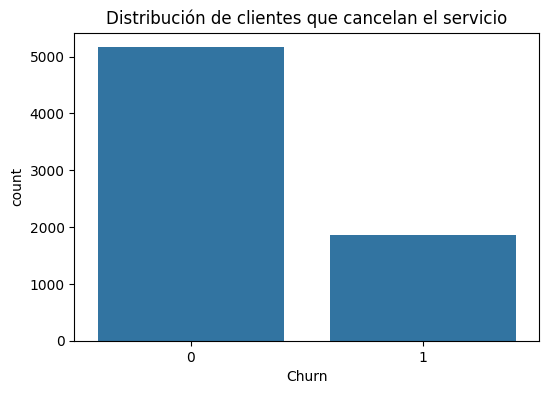

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(x="Churn", data=df)

plt.title("Distribución de clientes que cancelan el servicio")

plt.show()

###RECUENTO DE EVASIÓN POR VARIABLES CATEGÓRICAS

Ahora, exploraremos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

###Churn por tipo de contrato
Clientes con contrato mensual cancelan mucho más que los de contratos anuales.

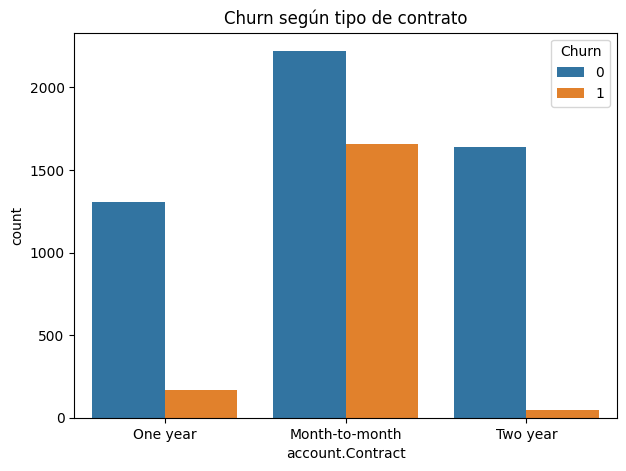

In [60]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="account.Contract",
    hue="Churn",
    data=df
)

plt.title("Churn según tipo de contrato")

plt.show()

###Churn por método de pago
Clientes con Electronic Check presentan mayor churn.

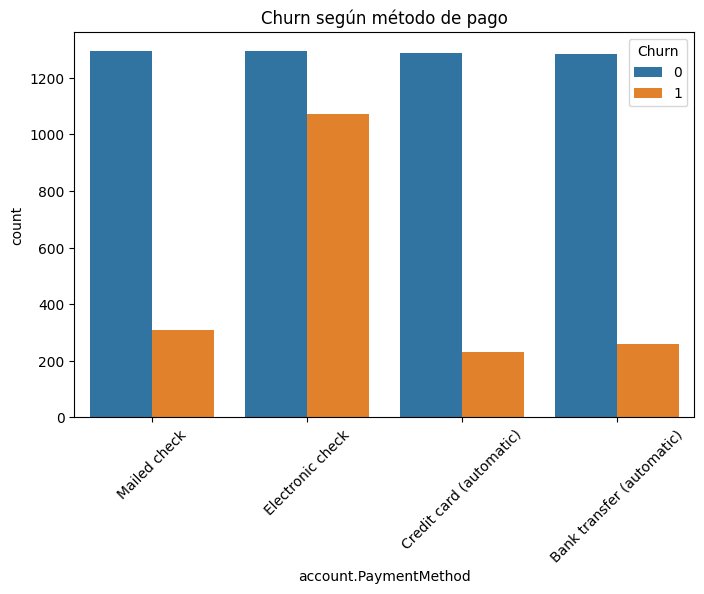

In [62]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="account.PaymentMethod",
    hue="Churn",
    data=df
)

plt.xticks(rotation=45)

plt.title("Churn según método de pago")

plt.show()

### Tipo de Servicio de Internet
Clientes con Firba Optica presentan mayor evasión

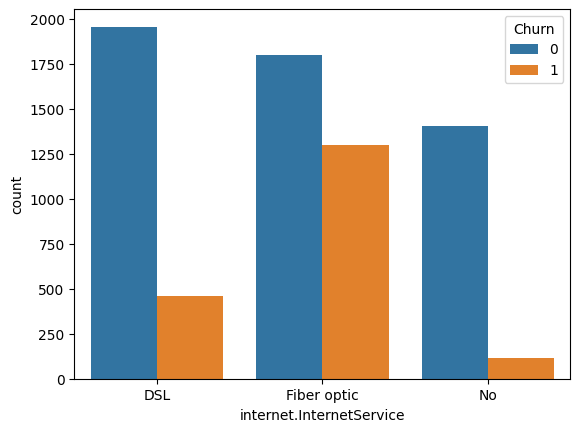

In [53]:
sns.countplot(x="internet.InternetService", hue="Churn", data=df)

plt.show()

###CONTEO DE EVASIÓN POR VARIABLES NUMÉRICAS

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

###Tenure vs Churn
Clientes que cancelan tienen menor antigüedad en la empresa.

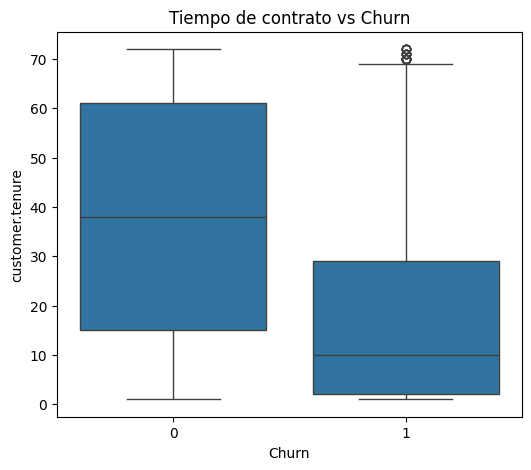

In [64]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Churn",
    y="customer.tenure",
    data=df
)

plt.title("Tiempo de contrato vs Churn")

plt.show()

###Cargos mensuales vs Churn
Clientes con cargos mensuales más altos tienden a cancelar más.

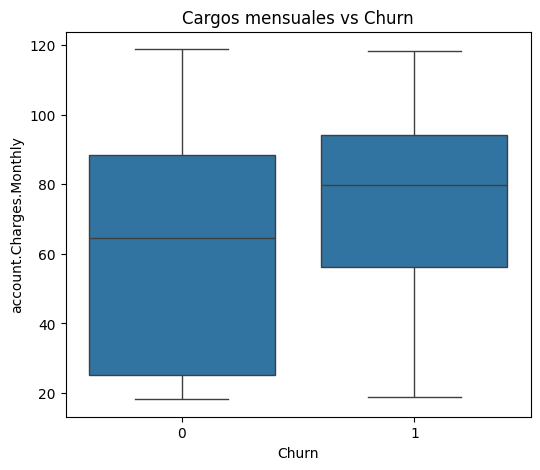

In [66]:
plt.figure(figsize=(6,5))

sns.boxplot(
    x="Churn",
    y="account.Charges.Monthly",
    data=df
)

plt.title("Cargos mensuales vs Churn")

plt.show()

# 📊 Informe Final — Análisis de Evasión de Clientes (Churn)

## Introducción

La evasión de clientes (Churn) es un problema importante para las empresas de telecomunicaciones, ya que implica pérdida de ingresos y mayores costos para adquirir nuevos clientes.  
El objetivo de este análisis es identificar **patrones y factores asociados a la cancelación del servicio en TelecomX**, utilizando análisis exploratorio de datos (EDA). Los resultados buscan apoyar estrategias que permitan **reducir la evasión y mejorar la retención de clientes**.

---

## Limpieza y Tratamiento de Datos

Los datos fueron importados desde un archivo JSON y normalizados para obtener una estructura tabular adecuada para el análisis.

Durante el proceso de limpieza se realizaron las siguientes acciones:

- Identificación de valores nulos mediante `df.isnull().sum()`.
- Se detectaron **11 valores nulos en `Charges.Total`**, correspondientes a clientes con `tenure = 0`.
- Estos registros fueron eliminados del dataset, ya que representan clientes nuevos sin historial de facturación.
- La variable `Charges.Total` fue convertida a tipo numérico.
- Se creó una nueva variable llamada **Cuentas_Diarias**, calculada a partir de los cargos mensuales.

---

## Análisis Exploratorio de Datos

Se realizaron distintos análisis y visualizaciones para identificar patrones asociados al churn.

Principales análisis realizados:

- **Distribución de clientes que cancelan el servicio**
- Relación entre **cargos diarios y evasión**
- Análisis de **antigüedad del cliente (tenure)**
- Relación entre **cantidad de servicios contratados y churn**

Los resultados mostraron que:

- Los clientes con **menor antigüedad tienen mayor probabilidad de cancelar**.
- Los clientes con **mayores cargos diarios presentan una ligera tendencia a churn**.
- Los clientes con **más servicios contratados tienden a permanecer más tiempo**.

---

## Conclusiones e Insights

A partir del análisis se identificaron algunos factores relevantes en la evasión de clientes:

- La **antigüedad del cliente (tenure)** es uno de los factores más importantes: los clientes nuevos cancelan con mayor frecuencia.
- Los **cargos mensuales más altos** muestran una ligera relación con la cancelación del servicio.
- Los clientes que contratan **más servicios adicionales tienden a mostrar mayor permanencia**.

Estos resultados sugieren que el churn está influenciado por múltiples factores relacionados con el comportamiento del cliente y las características del servicio.

---

## Recomendaciones

Basado en los resultados del análisis, se proponen las siguientes estrategias:

- Implementar **programas de fidelización para clientes nuevos**, ya que presentan mayor riesgo de cancelación.
- Evaluar estrategias de **precios y promociones** para clientes con cargos más elevados.
- Promover la contratación de **paquetes de múltiples servicios**, lo que puede aumentar la permanencia del cliente.
- Mejorar la **experiencia del cliente y la calidad del soporte**, especialmente en las primeras etapas del servicio.

---

## Conclusión

El análisis permitió identificar patrones importantes en el comportamiento de los clientes de TelecomX. Comprender los factores asociados al churn permite diseñar **estrategias de retención más efectivas**, lo que puede contribuir a mejorar la satisfacción del cliente y reducir la pérdida de usuarios.

#EXTRA - Análisis de correlación entre variables


###Relación entre cuenta diaria y churn
Existe una correlación positiva débil entre la cuenta diaria y la evasión de clientes.

In [67]:
df[["Cuentas_Diarias", "Churn"]].corr()

,Cuentas_Diarias,Churn
Cuentas_Diarias,1.000000,0.192858
Churn,0.192858,1.000000


###Histograma por churn
A medida que aumenta la cuenta diaria se observa una mayor proporción de churn (barras naranjas). En cuentas diarias bajas predomina que los clientes no cancelen

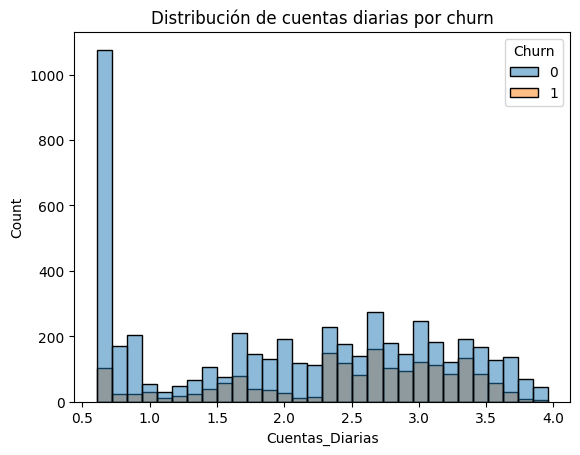

In [74]:
sns.histplot(
    data=df,
    x="Cuentas_Diarias",
    hue="Churn",
    bins=30
)

plt.title("Distribución de cuentas diarias por churn")

plt.show()

###Número de servicios contratados
clientes con más servicios tienden ligeramente a cancelar menos

In [70]:
servicios = [
    "internet.OnlineSecurity",
    "internet.OnlineBackup",
    "internet.DeviceProtection",
    "internet.TechSupport",Z
    "internet.StreamingTV",
    "internet.StreamingMovies"
]

df["Num_Servicios"] = df[servicios].apply(lambda x: (x == "Yes").sum(), axis=1)

In [71]:
df[["Num_Servicios", "Churn"]].corr()

,Num_Servicios,Churn
Num_Servicios,1.000000,-0.087882
Churn,-0.087882,1.000000


##Matriz de correlación general

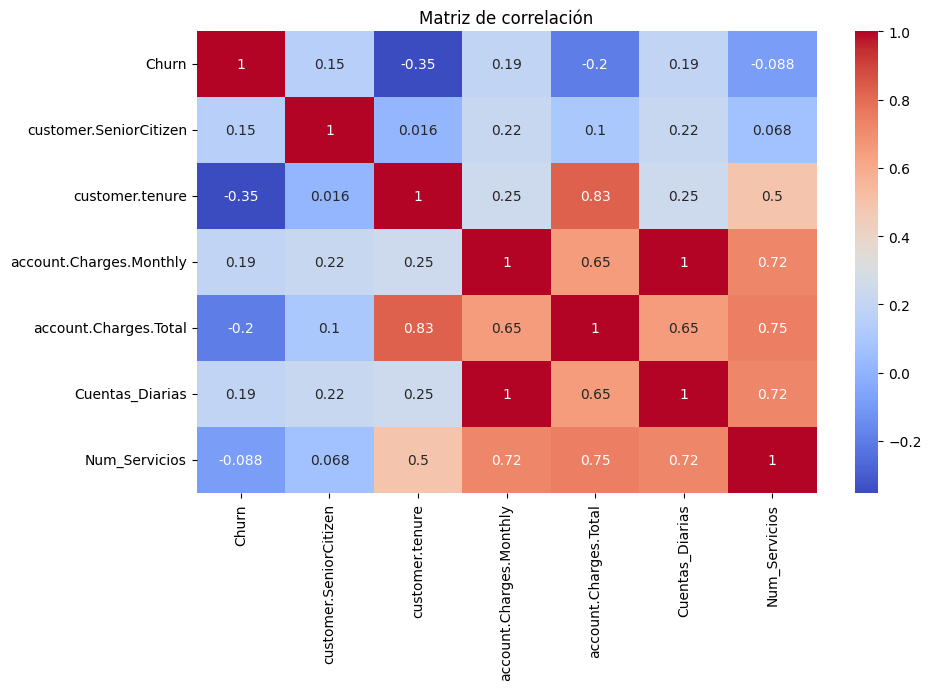

In [73]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")

plt.show()

##CONCLUSIÓN EXTRA!!
El análisis de correlación muestra que la antigüedad del cliente (tenure) presenta una relación negativa con la evasión, lo que indica que los clientes con mayor tiempo en la empresa tienen menor probabilidad de cancelar el servicio. Además, cargos mensuales más elevados muestran una relación positiva con la evasión, sugiriendo que el costo del servicio puede influir en la decisión de abandono. Asimismo, se observa que los clientes que contratan un mayor número de servicios adicionales presentan una menor tasa de churn.